# 213 — Metric choice under the MHC stress test

**Question:** kmerseek emits a dozen candidate similarity scores per pair. Which one should rank MHC
ortholog candidates, and does the genome-wide answer survive the hardest case?

Notebooks [200](./200_human_mouse_ortholog_alphabet_ksize_comparison.ipynb) and
[205](./205_hp_thomas_dill_deep_dive.ipynb) found that on HP alphabets, plain **jaccard beats every
p-value-based composite**: containment saturates near 1.0 for almost every candidate pair, so the
Poisson p-value carries no signal. That was established genome-wide and spot-checked on a handful of
MHC combos. This notebook generalises the check to every HP combo notebook 200 has validated, on the
MHC benchmark.

**Two things differ from the earlier spot-check**, both consequences of
[210](./210_mhc_benchmark_setup_and_label_policy.ipynb):

1. **Scored under all three label policies.** The old version used what amounted to `any_member`
   without saying so. A metric that ranks a gene's 15 partners well can look strong under
   `any_member` and mediocre under `synteny_nearest`.
2. **AUPRC is always reported against its prevalence.** Metric comparisons here run across k, and
   the candidate pool shrinks as k grows, so the positive fraction rises even with no change in
   ranking quality. A rising AUPRC curve alone cannot distinguish better ranking from a smaller,
   easier candidate pool. The baseline is plotted on every panel.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

import ortholog_analysis_utils as ou

RES = Path("/Users/olga/data/gencode/results-human-mouse-orthologs")
FIG_DIR = Path("../figures")

regions = pl.read_parquet(RES / "210_mhc_matched_regions.parquet")
pair = pl.read_parquet(RES / "210_mhc_pair_table.parquet")

combos_df = ou.load_all_alphabet_ksize_combos().filter(pl.col("dash_encoding") != "hp")
ALPHABET_DISPLAY_NAMES = dict(
    zip(combos_df["dash_encoding"].to_list(), combos_df["display_encoding"].to_list())
)

# Labels live on the PAIR table (one row per human/mouse pair); scoring here is per matched REGION,
# so the label columns are joined down onto regions rather than recomputed. This is the whole point
# of 210 writing a canonical table: 213 cannot invent a fourth, subtly different ground truth.
LABEL_COLS = list(ou.LABEL_POLICY_COLS.values())
regions = regions.join(
    pair.select(["combo", "human_gene", "mouse_gene", *LABEL_COLS]),
    on=["combo", "human_gene", "mouse_gene"],
    how="left",
)
for c in LABEL_COLS:
    regions = regions.with_columns(pl.col(c).fill_null(False))

HP_COMBOS = (
    regions.filter(pl.col("encoding").str.starts_with("hp"))
    .select(["combo", "encoding", "ksize"])
    .unique()
    .sort(["encoding", "ksize"])
)
BASELINE_COMBO = "protein_k15"
print(
    f"{HP_COMBOS.height} HP combos to score, across "
    f"{HP_COMBOS['encoding'].n_unique()} HP alphabets"
)
print(f"baseline kept for contrast (not part of the HP grid): {BASELINE_COMBO}")

54 HP combos to score, across 6 HP alphabets
baseline kept for contrast (not part of the HP grid): protein_k15


## 1. Score every HP combo under every metric and every label policy

Scoring uses the shared 12-metric definitions in `ou.add_composite_scores` / `ou.compute_aucs`, the
same ones notebooks 200/203/206 use, with a combo-specific Bonferroni/BH denominator (25 MHC query
genes × that combo's mouse-protein count) rather than a global one.

In [2]:
def score_combo(label: str, policy_col: str):
    sub = regions.filter(pl.col("combo") == label)
    if sub.height == 0 or sub[policy_col].n_unique() < 2:
        return None
    n_total = 25 * sub["target_name"].n_unique()
    p = sub["poisson_pvalue"].fill_null(1.0).to_numpy()
    sub = sub.with_columns(
        [
            pl.Series("poisson_p_bonf_conservative", np.clip(p * n_total, 0, 1)),
            pl.Series("poisson_p_bh_conservative", ou.bh_conservative(p, n_total)),
        ]
    )
    sub = ou.add_composite_scores(sub).with_columns(pl.col(policy_col).alias("label"))
    aucs = ou.compute_aucs(sub)
    return (aucs, float(sub[policy_col].cast(pl.Int8).mean())) if aucs else None


rows, prev_rows, skipped = [], [], []
for combo, enc, k in HP_COMBOS.iter_rows():
    for policy, col in ou.LABEL_POLICY_COLS.items():
        res = score_combo(combo, col)
        if not res:
            skipped.append((combo, policy))
            continue
        aucs, prevalence = res
        prev_rows.append(
            {
                "combo": combo,
                "encoding": enc,
                "ksize": k,
                "policy": policy,
                "prevalence": prevalence,
            }
        )
        for metric, v in aucs.items():
            rows.append(
                {
                    "combo": combo,
                    "encoding": enc,
                    "ksize": k,
                    "policy": policy,
                    "metric": metric,
                    **v,
                }
            )
metric_df = pl.DataFrame(rows)
prevalence_df = pl.DataFrame(prev_rows)
print(
    f"Scored {metric_df['combo'].n_unique()}/{HP_COMBOS.height} HP combos "
    f"x {metric_df['metric'].n_unique()} metrics x {metric_df['policy'].n_unique()} policies"
)
if skipped:
    print(
        f"Skipped (no rows, or single-class labels under that policy): {len(skipped)} combo-policy pairs"
    )

# Which metric wins, per policy -- the actual question.
print()
for policy in ou.LABEL_POLICIES:
    sub = metric_df.filter(pl.col("policy") == policy)
    if sub.height == 0:
        continue
    winners = (
        sub.sort("pr_auc", descending=True)
        .group_by("combo", maintain_order=True)
        .first()["metric"]
        .value_counts()
        .sort("count", descending=True)
    )
    n = sub["combo"].n_unique()
    top = winners.row(0)
    print(
        f"{ou.LABEL_POLICY_LABELS[policy]:32s} winner: {top[0]:24s} "
        f"{top[1]}/{n} combos ({100 * top[1] / n:.0f}%)"
    )

Scored 54/54 HP combos x 12 metrics x 3 policies

any MGI member                   winner: jaccard                  48/54 combos (89%)
best-scoring member (circular)   winner: jaccard                  26/54 combos (48%)
syntenically nearest             winner: score_enr_cont_freq      29/54 combos (54%)


Best metric per (alphabet, ksize) under syntenically nearest:
shape: (12, 5)
┌─────────────────────┬───────┬─────────────────────┬──────────┬──────────┐
│ encoding            ┆ ksize ┆ metric              ┆ pr_auc   ┆ roc_auc  │
│ ---                 ┆ ---   ┆ ---                 ┆ ---      ┆ ---      │
│ str                 ┆ i64   ┆ str                 ┆ f64      ┆ f64      │
╞═════════════════════╪═══════╪═════════════════════╪══════════╪══════════╡
│ hp-lehninger-plus-c ┆ 29    ┆ score_enr_cont_freq ┆ 0.942081 ┆ 0.997273 │
│ hp-lehninger-plus-c ┆ 30    ┆ score_enr_cont_freq ┆ 0.936056 ┆ 0.994691 │
│ hp-lehninger        ┆ 29    ┆ score_enr_cont_freq ┆ 0.934448 ┆ 0.995345 │
│ hp-lehninger        ┆ 28    ┆ score_enr_cont_freq ┆ 0.934071 ┆ 0.997236 │
│ hp-lehninger        ┆ 27    ┆ score_enr_cont_freq ┆ 0.93106  ┆ 0.998549 │
│ …                   ┆ …     ┆ …                   ┆ …        ┆ …        │
│ hp-lehninger-plus-c ┆ 27    ┆ score_enr_cont_freq ┆ 0.92261  ┆ 0.999207 │
│ hp-lehnin

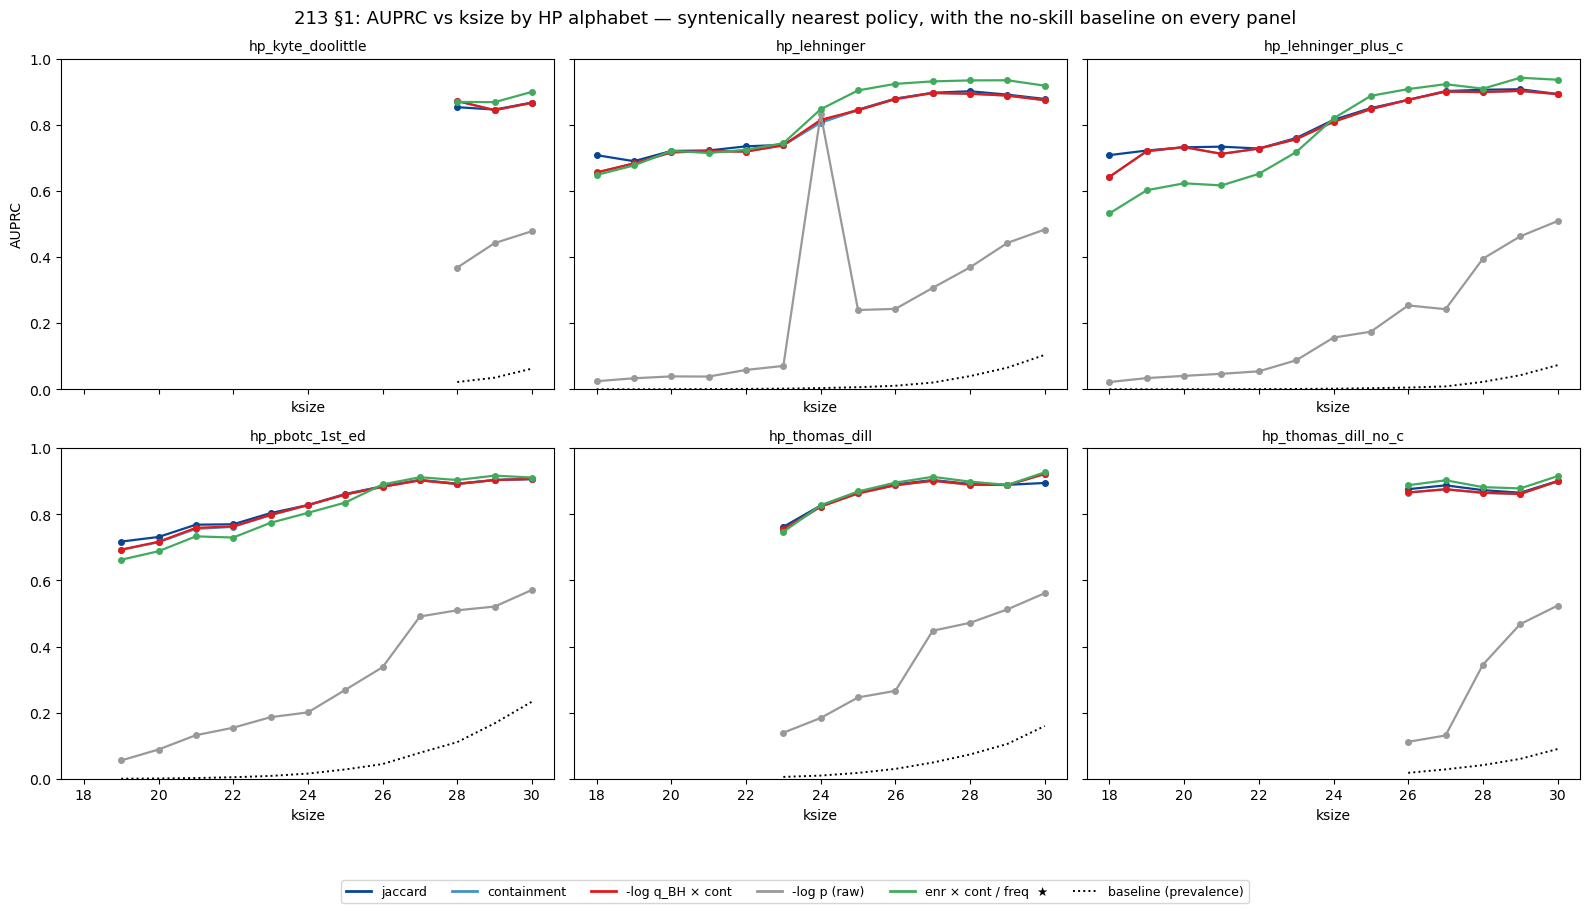

In [3]:
# Figure: AUPRC vs ksize, one subplot per HP alphabet, one line per representative metric, for the
# HEADLINE policy -- with the prevalence baseline drawn on every panel, because AUPRC compared
# across k without it cannot distinguish better ranking from a smaller candidate pool.
KEY_METRICS = [
    "jaccard",
    "containment",
    "score_bh_neglogq_cont",
    "score_neglogp",
    "score_enr_cont_freq",
]
metric_colors = dict(
    zip(KEY_METRICS, ["#084594", "#4292c6", "#e31a1c", "#999999", "#41ab5d"])
)
HEADLINE = "synteny_nearest"
hp_alphabets = sorted(
    HP_COMBOS["encoding"].unique().to_list(),
    key=lambda e: ALPHABET_DISPLAY_NAMES.get(e, e),
)

fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=True, sharex=True)
axes = axes.flatten()
for ax, enc in zip(axes, hp_alphabets):
    sub = metric_df.filter((pl.col("encoding") == enc) & (pl.col("policy") == HEADLINE))
    for metric in KEY_METRICS:
        m = sub.filter(pl.col("metric") == metric).sort("ksize")
        if m.height == 0:
            continue
        ax.plot(
            m["ksize"], m["pr_auc"], "o-", color=metric_colors[metric], lw=1.6, ms=4
        )
    pv = prevalence_df.filter(
        (pl.col("encoding") == enc) & (pl.col("policy") == HEADLINE)
    ).sort("ksize")
    ax.plot(pv["ksize"], pv["prevalence"], ":", color="black", lw=1.4)
    ax.set_title(ALPHABET_DISPLAY_NAMES.get(enc, enc), fontsize=10)
    ax.set_xlabel("ksize")
    ax.set_ylim(0, 1.0)
axes[0].set_ylabel("AUPRC")
for ax in axes[len(hp_alphabets) :]:
    ax.axis("off")
handles = [
    plt.Line2D([0], [0], color=metric_colors[m], lw=2, label=ou.SCORE_LABELS.get(m, m))
    for m in KEY_METRICS
]
handles.append(
    plt.Line2D([0], [0], color="black", lw=1.4, ls=":", label="baseline (prevalence)")
)
fig.legend(
    handles=handles,
    loc="lower center",
    ncol=len(KEY_METRICS) + 1,
    fontsize=9,
    bbox_to_anchor=(0.5, -0.02),
)
fig.suptitle(
    f"213 §1: AUPRC vs ksize by HP alphabet — {ou.LABEL_POLICY_LABELS[HEADLINE]} policy, "
    f"with the no-skill baseline on every panel",
    fontsize=13,
)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig(FIG_DIR / "213_metric_auprc_vs_ksize.png", dpi=150, bbox_inches="tight")

# Numbers behind the figure: per-alphabet best metric and its AUPRC against the baseline drawn
# as the dotted line, so the panels can be read without measuring pixels.
best_per_alphabet = (
    metric_df.filter(pl.col("policy") == HEADLINE)
    .sort("pr_auc", descending=True)
    .group_by(["encoding", "ksize"], maintain_order=True)
    .first()
    .sort("pr_auc", descending=True)
    .select(["encoding", "ksize", "metric", "pr_auc", "roc_auc"])
)
print(f"Best metric per (alphabet, ksize) under {ou.LABEL_POLICY_LABELS[HEADLINE]}:")
print(best_per_alphabet.head(12))
print(
    "\nAUPRC baseline (prevalence, the dotted line) per alphabet -- median across its k range:"
)
print(
    prevalence_df.filter(pl.col("policy") == HEADLINE)
    .group_by("encoding")
    .agg(pl.col("prevalence").median().round(4).alias("median_baseline"))
    .sort("median_baseline", descending=True)
)

## 2. Does the winning metric depend on the label policy?

If jaccard wins under every policy, the recommendation is robust and the policy discussion does not
touch it. If the winner changes, the earlier "use jaccard" advice was partly an artifact of an
unstated label rule.

shape: (14, 3)
┌─────────────────────┬─────────────────────────┬─────┐
│ policy              ┆ metric                  ┆ len │
│ ---                 ┆ ---                     ┆ --- │
│ str                 ┆ str                     ┆ u32 │
╞═════════════════════╪═════════════════════════╪═════╡
│ any_member          ┆ jaccard                 ┆ 48  │
│ any_member          ┆ score_tfidf_cont        ┆ 3   │
│ any_member          ┆ score_enr_cont_freq     ┆ 2   │
│ any_member          ┆ score_bonf_neglogp_cont ┆ 1   │
│ best_scoring_member ┆ jaccard                 ┆ 26  │
│ …                   ┆ …                       ┆ …   │
│ synteny_nearest     ┆ score_tfidf_cont        ┆ 17  │
│ synteny_nearest     ┆ jaccard                 ┆ 3   │
│ synteny_nearest     ┆ score_enr_cont          ┆ 2   │
│ synteny_nearest     ┆ enrichment              ┆ 2   │
│ synteny_nearest     ┆ score_neglogp_cont      ┆ 1   │
└─────────────────────┴─────────────────────────┴─────┘

any MGI member  (n=54 combos)
  

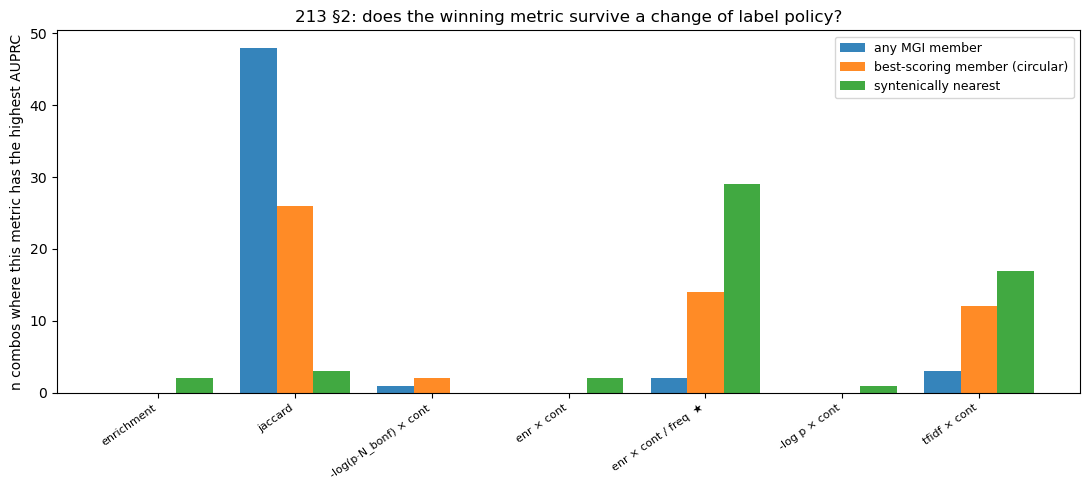

In [4]:
win_by_policy = (
    metric_df.sort("pr_auc", descending=True)
    .group_by(["policy", "combo"], maintain_order=True)
    .first()
    .group_by(["policy", "metric"])
    .len()
    .sort(["policy", "len"], descending=[False, True])
)
print(win_by_policy)

# Head-to-head: jaccard vs the best p-value composite, per combo, per policy.
head = metric_df.filter(
    pl.col("metric").is_in(["jaccard", "containment", "score_bh_neglogq_cont"])
).pivot(index=["combo", "policy"], on="metric", values="pr_auc")
for policy in ou.LABEL_POLICIES:
    h = head.filter(pl.col("policy") == policy).drop_nulls()
    if h.height == 0:
        continue
    print(f"\n{ou.LABEL_POLICY_LABELS[policy]}  (n={h.height} combos)")
    print(
        f"  jaccard beats containment in            {int((h['jaccard'] > h['containment']).sum())}/{h.height}"
    )
    print(
        f"  jaccard beats score_bh_neglogq_cont in  {int((h['jaccard'] > h['score_bh_neglogq_cont']).sum())}/{h.height}"
    )
    print(
        f"  median AUPRC -- jaccard {h['jaccard'].median():.3f} | "
        f"containment {h['containment'].median():.3f} | "
        f"bh_neglogq_cont {h['score_bh_neglogq_cont'].median():.3f}"
    )

# Figure: win counts per metric, one group of bars per policy.
fig, ax = plt.subplots(figsize=(11, 5))
policies = [p for p in ou.LABEL_POLICIES if p in win_by_policy["policy"].to_list()]
metrics_seen = win_by_policy["metric"].unique().to_list()
cmap = plt.get_cmap("tab20")
mcolor = {m: cmap(i % 20) for i, m in enumerate(sorted(metrics_seen))}
w = 0.8 / max(len(policies), 1)
for pi, policy in enumerate(policies):
    sub = win_by_policy.filter(pl.col("policy") == policy)
    lookup = dict(zip(sub["metric"].to_list(), sub["len"].to_list()))
    xs = np.arange(len(sorted(metrics_seen)))
    ax.bar(
        xs + pi * w,
        [lookup.get(m, 0) for m in sorted(metrics_seen)],
        width=w,
        label=ou.LABEL_POLICY_LABELS[policy],
        alpha=0.9,
    )
ax.set_xticks(np.arange(len(metrics_seen)) + w)
ax.set_xticklabels(
    [ou.SCORE_LABELS.get(m, m) for m in sorted(metrics_seen)],
    rotation=35,
    ha="right",
    fontsize=8,
)
ax.set_ylabel("n combos where this metric has the highest AUPRC")
ax.set_title(
    "213 §2: does the winning metric survive a change of label policy?", fontsize=12
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "213_metric_wins_by_policy.png", dpi=150, bbox_inches="tight")

## 3. The `protein_k15` baseline, kept for contrast

Not part of the HP grid. Included because it illustrates that "rank 1" is a relative statement: if
every metric on a combo scores below chance, the top-ranked one is winning a contest where every
entrant already lost.

protein_k15 under any MGI member: baseline 0.54938 | best ROC-AUC 0.459 | metrics below chance: 12/12
protein_k15 under best-scoring member (circular): baseline 0.19136 | best ROC-AUC 0.928 | metrics below chance: 0/12
protein_k15 under syntenically nearest: baseline 0.17284 | best ROC-AUC 0.892 | metrics below chance: 0/12

Same combo, same data, same 12 metrics: best ROC-AUC 0.459 under any_member vs 0.892 under synteny_nearest.

Wrote 213_mhc_metric_leaderboard.csv (1,944 rows)


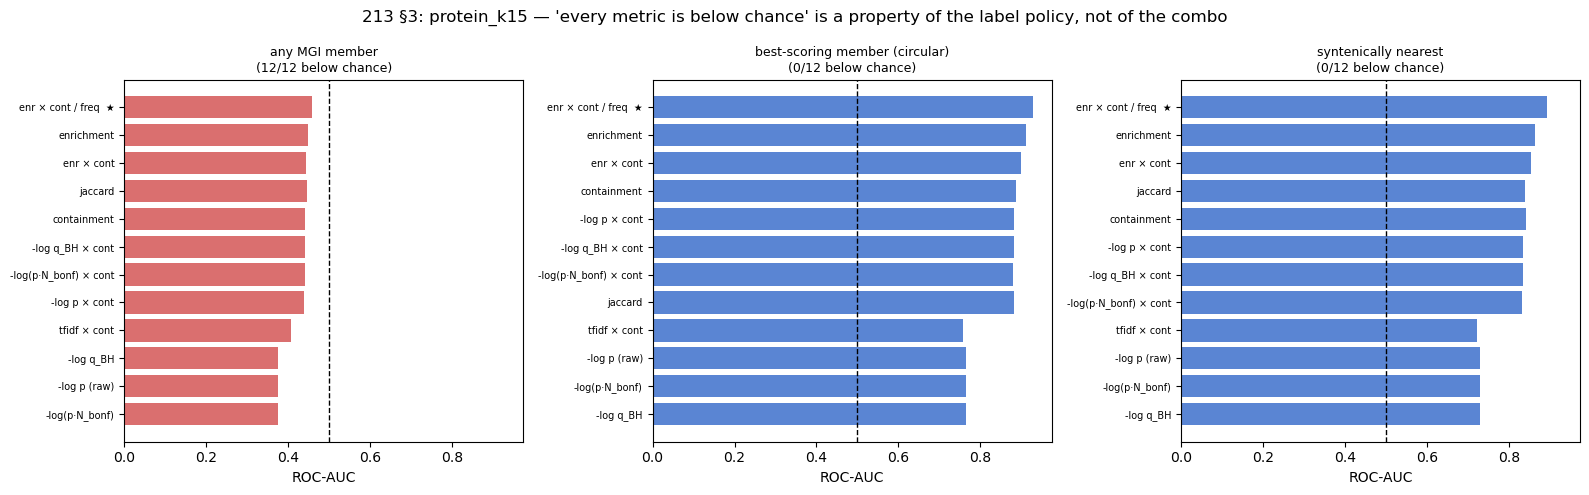

In [5]:
# Scored under all three policies, not just the headline: an earlier version of this analysis
# reported that EVERY metric on protein_k15 falls below chance. That turns out to be a statement
# about the `any_member` label rule, not about protein_k15 -- so all three are shown side by side.
baseline_lbs = {}
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True)
for ax, policy in zip(axes, ou.LABEL_POLICIES):
    res = score_combo(BASELINE_COMBO, ou.LABEL_POLICY_COLS[policy])
    if not res:
        ax.axis("off")
        continue
    aucs, prevalence = res
    lb = pl.DataFrame([{"metric": m, **v} for m, v in aucs.items()]).sort(
        "pr_auc", descending=True
    )
    lb = lb.with_columns(pl.arange(1, lb.height + 1).alias("rank"))
    baseline_lbs[policy] = (lb, prevalence)
    n_below = int((lb["roc_auc"] < 0.5).sum())
    print(
        f"{BASELINE_COMBO} under {ou.LABEL_POLICY_LABELS[policy]}: "
        f"baseline {prevalence:.5f} | best ROC-AUC {lb['roc_auc'].max():.3f} "
        f"| metrics below chance: {n_below}/{lb.height}"
    )

    y = np.arange(lb.height)
    ax.barh(
        y,
        lb["roc_auc"],
        color=["#D65F5F" if v < 0.5 else "#4878CF" for v in lb["roc_auc"]],
        alpha=0.9,
    )
    ax.axvline(0.5, color="k", ls="--", lw=1)
    ax.set_yticks(y)
    ax.set_yticklabels([ou.SCORE_LABELS.get(m, m) for m in lb["metric"]], fontsize=7)
    ax.invert_yaxis()
    ax.set_xlabel("ROC-AUC")
    ax.set_title(
        f"{ou.LABEL_POLICY_LABELS[policy]}\n({n_below}/{lb.height} below chance)",
        fontsize=9,
    )
fig.suptitle(
    f"213 §3: {BASELINE_COMBO} — 'every metric is below chance' is a property of the "
    f"label policy, not of the combo",
    fontsize=12,
)
plt.tight_layout()
plt.savefig(FIG_DIR / "213_protein_baseline.png", dpi=150, bbox_inches="tight")


if "any_member" in baseline_lbs and HEADLINE in baseline_lbs:
    a, _ = baseline_lbs["any_member"]
    s, _ = baseline_lbs[HEADLINE]
    print(
        f"\nSame combo, same data, same 12 metrics: best ROC-AUC {a['roc_auc'].max():.3f} "
        f"under any_member vs {s['roc_auc'].max():.3f} under {HEADLINE}."
    )

metric_df.write_csv(RES / "213_mhc_metric_leaderboard.csv")
print(f"\nWrote 213_mhc_metric_leaderboard.csv ({metric_df.height:,} rows)")

## Verdict

**"Jaccard wins" does not survive the label policy; the earlier claim was measuring the policy as
much as the metric.**

Under `any_member`, the rule the earlier spot-check used without naming it, jaccard has the highest
AUPRC in **48/54 combos (89%)**, reproducing the published claim. Under `synteny_nearest`, jaccard
wins **3/54**, and `score_enr_cont_freq` leads with 29/54 (54%), followed by `score_tfidf_cont` at
17/54. The metric ranking is not a stable property of the HP alphabets.

**But the collapse is a compression, not a reversal, and the practical advice barely moves.** The
head-to-head numbers matter more than the win counts: under `synteny_nearest`, jaccard still beats
containment in **49/54** combos and the BH composite in **47/54**. What changed is the *margin* —
median AUPRC is 0.863 (jaccard) vs 0.862 (containment) vs 0.863 (BH composite), a three-way tie
inside noise. When a field compresses into a tie, "which metric wins" becomes an arbitrary tiebreak,
and counting wins across 54 correlated combos makes that arbitrariness look like a result.
**Report the head-to-head margins, not the win count.**

**Revised recommendation.** On HP alphabets, jaccard remains a defensible default: it is never
meaningfully worse than containment or a p-value composite under any policy, and it is clearly
better under the loose one. It should not be presented as a decisive winner, and any claim of the
form "metric X wins on N of M combos" needs the label policy attached.

**The protein baseline claim also inverts.** The earlier write-up stated that on `protein_k15` every
one of the 12 metrics scores below chance. That is true under `any_member` and false under
`synteny_nearest`, where **0/12** fall below chance and the best metric reaches ROC-AUC 0.892 on the
same data with the same 12 metrics. "Protein cannot rank MHC candidates at all" described the
labelling, not protein. What survives is narrower: protein's containment saturates, so p-value-
derived scores lose resolution, visible in §3 as the three raw p-value scores clustering at an
identical AUPRC of 0.308 while the enrichment-family scores separate.

**What jaccard winning does *not* mean.** Both `containment = |A∩B| / |A|` and
`jaccard = |A∩B| / |A∪B|` are computed over the **whole-protein** minhash signature in kmerseek
(`calculate_similarity_from_precomputed`, `search.rs`). `query_start`/`query_end`/`region_length`,
used throughout [212](./212_mhc_domain_localisation.ipynb) and
[214](./214_mhc_igsf_specificity.ipynb), are **positional metadata** describing where the
intersecting hashes map back onto the sequence (`find_matched_regions`); they never rescope the
containment or jaccard denominator to that region. Every search in this block is therefore
whole-human-protein vs whole-mouse-protein.

That matters because containment's advantage over jaccard is a **size-asymmetry** advantage:
`containment(A given B)` stays high when B is much larger than A, whereas jaccard's union
denominator is diluted by B's extra bulk. When `|query| ≈ |target|`, true for two full-length MHC
orthologs, the two converge and neither has a structural edge. **Jaccard winning here is not
evidence that containment loses at domain-level detection in general; this benchmark never created
the size asymmetry that would let containment's advantage appear.** The search that would: query
with the ~180 aa ARD sequence alone against full-length targets. That is structurally different from
anything run in this block, and is the natural follow-up if the domain-containment question matters
for a future benchmark.